# Feature analysis — `ofi_normalised`

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`ema_ofi` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `ofi_normalised`: a single trade-clock EMA of each venue's level-1 order-flow
imbalance — net signed pressure on the touch — read against a byb regime yardstick, compared three
ways (un-normalised, ÷ σ_ev, ÷ λ_ev). Positive OFI is order flow leaning up; the prediction is byb's
mid follows. It is a textbook **price-head (direction)** feature, and we check the rate head too.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

**Why this matters for OFI.** `ema(OFI)` predicts a venue's *direction* (more bid pressure → it ticks
up), so its home is the price head; but a large *magnitude* of imbalance also tends to precede a burst
of moves, so we check the rate head too. We reuse **exactly** the two byb yardsticks here — both as the
price/rate targets *and* as the two normalisers under test — which is why byb's own OFI leg is partly
circular with them, and the okx/bin legs are not (see §5/§6's marginal-value reading).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (this one *is* poolable — a per-exchange number built from each venue's own
  book, not a gap *between* exchanges), first check per-exchange vs single vs pooled across
  time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — so this notebook **measures** which normalisation helps rather than assuming: raw
  OFI is a *size* (contracts), bigger when the book churns, so it *may* carry regime — but `σ_ev`
  (a return) and `λ_ev` (a rate) share no units with a size, so the division is a regime gauge,
  not a units fix. We test `none` / `/σ_ev` / `/λ_ev` and let the gates decide.
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the OFI EMA,
  `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a book update on its own exchange — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For OFI, that relevant event is a *book
  update* of its own exchange: it injects that timestamp's one OFI increment. A value that ignores its own
  book updates since the last clock read is **stale** — wrong, and a silent source of lag. The choice of EMA
  *and when it updates* is what makes the read well-behaved — pick both deliberately (see the "Choosing the
  EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for OFI, a book update on *this* exchange; for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); for OFI we collapse a burst of book rows to the **final**
  top-of-book at that timestamp and form **one** OFI increment from the previous distinct timestamp's book.
  So a backed-up burst of N book updates at one instant is still **one** weight-1 sample — value = one OFI
  increment off the final book — **never** N samples (and never N−1 phantom intra-instant increments).
  Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight on the `E/W` mean at one timestamp) and corrupts the count `W` that normalises it.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (here, an exchange's own
  OFI increments — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that buy pressure on one exchange can cancel sell pressure on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass, and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | a single trade-clock EMA of each venue's level-1 order-flow imbalance, normalised by a byb regime yardstick — one leg per venue (byb / okx / bin), three readings: none / ÷σ_ev / ÷λ_ev |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** *Order-flow imbalance* (OFI) measures, between two consecutive top-of-book snapshots,
the **net signed size pressure** at the best bid and ask: size added on the bid and size removed
from the ask both push the price **up**; the reverse pushes it **down**. We use the level-1
**Cont–Kukanov–Stoikov** OFI (Cont, Kukanov & Stoikov, 2014, *J. Financial Econometrics*; definition
in §2). The sum `e` is positive when buy pressure dominates. We smooth `e` with **one** trade-clock
EMA (`ema(OFI)`, swept as a span family) — and then **normalise** so the same number means the same
thing in calm and wild markets. Because there are two regime yardsticks in this project, there are two
ways to normalise — and a feature-analysis notebook should *pick*, not assume. So this notebook
**builds and compares three readings of the same feature**: `ema(OFI)/σ_ev` (vol yardstick),
`ema(OFI)/λ_ev` (rate yardstick), and the un-normalised `ema(OFI)` baseline — and lets the hygiene
gates say which normalisation (if any) actually helps. We do this **once per venue**.

**Why it should work, and why per-exchange.** OFI is the most direct microstructure read on *who is
winning right now* at the touch, and the classic result (Cont–Kukanov–Stoikov) is that
**contemporaneous price change is close to linear in OFI**. The open question for *us* is predictive,
at ~100 ms — and it has two flavours:
- **byb's own OFI → byb** (the target reading byb's own pressure): a persistent bid-side imbalance on
  byb should pull byb's mid up over the next beat. Strong, but **circular** with byb's vol/rate
  controls (both are built from byb's own activity).
- **okx / bin OFI → byb** (the **cross-venue lead/lag** legs): does *another* venue's order-flow move
  *before* byb does? This is the genuinely new question — the same lead/lag idea the template's
  cross-venue gap exploits, but read through order-flow instead of price.

> **No fixed leader (per the guard rails).** Leadership rotates — any venue can lead at any moment. So
> we build OFI **the same way for every venue and keep all three**; we never hard-code one as the
> leader, and we never pick "the best venue." §6 sweeps all three; §9 asks *when* keeping them
> separate pays off.

**Why normalise, and the dimensional caveat.** Raw OFI is a **size** (contracts), and quiet markets
post smaller quotes than busy ones, so the *same* imbalance reads bigger in a busy regime — that's
regime contamination we want gone. Dividing by a yardstick rescales it to be **comparable across
regimes**. But note the caveat plainly: `σ_ev` is a *return* (per move) and `λ_ev` is a *rate* (moves
per second) — neither shares units with a size, so **this normalisation is for regime-comparability,
not dimensional consistency**. The division is a *regime gauge*, not a units conversion; we test
empirically whether the vol gauge, the rate gauge, or neither actually helps.

**What would disprove it.** No predictive power for `ema(OFI)` at any span, on either head; or power
that vanishes once we account for how volatile / busy the market is (meaning it only tracked the
regime). For the **cross-venue legs** specifically: the test is whether okx/bin OFI add over byb's
controls *and over byb's own OFI leg* — if they add ≈0, there is no exploitable cross-venue order-flow
lead at this horizon; if they add materially, the cross-venue lead is real.

## Choosing the EMA — and why OFI is a *flow*, read `E/W`

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). A wrong choice fails **silently**; choose the
EMA type and injection rule for the statistic being measured.

**OFI is a sparse FLOW**, exactly like `σ_ev`. It is defined only on a venue's **book updates** (a new
top-of-book), not on every event, and we want the *average imbalance per book update* — not a sum that
grows with how chatty that venue's quote feed is. So `ema(OFI_ex)` is a **`KernelMeanEMA`** read as the
self-normalising ratio `E / W`:

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (a per-venue OFI flow; byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. `add(e)` on each book update (weight 1) — `E`
  accumulates exp-weighted OFI, `W` counts the book updates; `tick()` once per trade-timestamp on the
  SHARED clock — decay both; read `E / W` = the **per-book-update mean OFI** as of now. This is the same
  machine as `σ_ev`, pointed at a different flow (OFI increments instead of squared mid-moves).
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; OFI is a flow, not a level, so it does **not** use it.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (OFI: push one increment only on a venue book update; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

The two between-trade rules still hold: **records sharing a timestamp are ONE event** (we collapse
each venue's front_levels to one row per `rx_time` — its final top-of-book — before forming
consecutive-pair OFI, so a same-instant burst of snapshots is one update, not a sequence of phantom
moves), and a timestamp with trades advances the decay clock **once**, not once per print.

## 2. The exact definition

A definition has to get three things right.

**Causal** — every value uses only book updates and trades at-or-before the moment it is read; no
forward-fill of the future. **On the trade clock** — progress is counted in trade-timestamps (one tick
per trade-timestamp on any venue; simultaneous prints are one tick), so the EMA's memory is in trades,
not seconds. Book updates between trades inject OFI and refresh the read, but do **not** advance the
clock. **Comparable across regimes** — OFI is a raw size, so we divide by a yardstick (and compare
which one). **Per venue** — one OFI leg each for byb / okx / bin.

**The raw atom — level-1 OFI (Cont–Kukanov–Stoikov).** For two consecutive *distinct-timestamp*
top-of-book rows of an exchange's book (`prev` → `cur`):

```
e =  (cur_bid_prc >= prev_bid_prc) ? cur_bid_qty  : 0      # bid improved/held -> buy-side depth added
   - (cur_bid_prc <= prev_bid_prc) ? prev_bid_qty : 0      # bid worsened/held -> buy-side depth removed
   - (cur_ask_prc <= prev_ask_prc) ? cur_ask_qty  : 0      # ask improved/held -> sell-side depth added
   + (cur_ask_prc >= prev_ask_prc) ? prev_ask_qty : 0      # ask worsened/held -> sell-side depth removed
```

The sum `e` is positive when buy pressure dominates. Putting the three together, for each venue `ex`:

**2a — The shape** (one line, three readings of the same OFI EMA):

- `ofi_raw[ex] = ema(OFI_ex)`                         — the un-normalised baseline (a size)
- `ofi_over_sigma[ex] = ema(OFI_ex) / σ_ev`           — variant **(A)**, vol yardstick
- `ofi_over_lambda[ex] = ema(OFI_ex) / λ_ev`          — variant **(B)**, rate yardstick

`ema(OFI_ex)` is one trade-clock EMA of venue `ex`'s OFI flow (span swept as a family). `σ_ev` and
`λ_ev` are read at the grid anchor — the *same* (byb-derived) yardsticks the model's two heads use, for
**every** venue's leg (we predict byb, so we normalise by byb's regime even for okx/bin OFI). Stop here
and you have the feature — the rest is making each piece correct.

**2b — The pieces, and how they update:**

- **`ema(OFI_ex)`** is a **`KernelMeanEMA`** read `E/W`: `add(e)` on every venue-`ex` book update (OFI
  computed from `ex`'s front_levels consecutive top-of-book rows), `tick()` once per trade-timestamp on
  the SHARED clock, read `E/W` = mean OFI per `ex` book update. `α = 2/(span+1)` cancels in the `E/W`
  ratio, so only the relative kernel weights matter.
- **`σ_ev`, `λ_ev`** are the project yardsticks — each a **`KernelMeanEMA`** `E/W` over **byb's**
  mid-move stream (push `return²` / `1` only on a real byb move; decay every trade): `σ_ev = √(E/W)` =
  RMS move per move; `λ_ev = W ÷ (seconds-per-trade EMA)` = byb moves per second. Span `YARDSTICK_N`.

Both reads obey the two between-trade rules above. §3 builds exactly this (all three readings × three
venues, across the span family); §4 re-derives `ema(OFI_ex)` from raw events one at a time — a
**production-style streaming build using `boba.ema`'s `KernelMeanEMA`** — and confirms it matches §3's
vectorized path to floating-point precision on a real block **for every venue**.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock at span `YARDSTICK_N` — verbatim from the template's machinery.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — and whose moves define the yardsticks/targets
EXCHANGES   = ["byb", "okx", "bin"]              # OFI is per venue; byb = own-book leg, okx/bin = CROSS-VENUE lead/lag legs
# freshest mid per exchange (for the TARGET and the vol/rate controls). byb/okx use merged_levels; bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). This is policy, not tuning. (OFI itself ALWAYS uses front_levels.)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]   # the FULL ema(OFI) span family to sweep (trades) — picked per head off the grid
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH (byb) yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1)) — fixed
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data
print("block:", block)

# the trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints (bin-perp insurance/ADL)
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid stream (merged_levels: trade-augmented, fresher) — used ONLY for the yardsticks + targets (the OFI itself needs qty, so it uses front_levels below)
byb_mer = (load_block(block, TARGET, "merged_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls())
byb_rx0  = byb_mer["rx_time"].cast(pl.Int64).to_numpy()
byb_mid0 = (byb_mer["bid_prc"].to_numpy() + byb_mer["ask_prc"].to_numpy()) / 2

# --- the yardsticks (σ_ev, λ_ev): react to every byb mid-move, decay once per trade. Identical to the template. ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, src_rx, val, span):   # EWMA of `val` over an EVENT stream `src_rx`, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, src_rx, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(src_rx, anchors, "right")] - cs[np.searchsorted(src_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

block: holocron.20260520T135822.0


trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


### Build the OFI flow — per venue

Now the feature-specific part, **for each venue**: load that venue's raw **front_levels** (the only
stream carrying `bid_qty` / `ask_qty` — `merged_levels` is price-only by design), collapse same-`rx_time`
bursts to one row (its final top-of-book — records sharing a nanosecond are ONE event), form the
Cont–Kukanov–Stoikov `e` on each consecutive distinct-timestamp pair, and inject it as a flow on the
SHARED trade clock. `_flow_at` (above) gives the committed-`E`/`W` read at any anchor; `ema(OFI_ex)` is
the ratio `E/W`. This is the same `E/W` machine as the yardsticks, fed each venue's OFI stream. We store
the per-venue OFI streams in dicts keyed by exchange.

In [2]:
# --- the OFI flow on a venue's own book: one increment e per distinct-timestamp book change ---
ofi_rx_by_ex = {}    # ex -> rx_time of each OFI event (the cur row's rx)
ofi_e_by_ex  = {}    # ex -> the Cont–Kukanov–Stoikov e for each event
raw_fl_by_ex = {}    # ex -> (frx0, bp0, bq0, ap0, aq0) raw un-collapsed columns (for the §4 oracle)
for ex in EXCHANGES:
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls())
    frx0 = fl["rx_time"].cast(pl.Int64).to_numpy()
    bp0, bq0, ap0, aq0 = (fl[c].to_numpy() for c in ("bid_prc", "bid_qty", "ask_prc", "ask_qty"))
    raw_fl_by_ex[ex] = (frx0, bp0, bq0, ap0, aq0)
    fl_keep = np.concatenate([frx0[1:] != frx0[:-1], [True]])                    # last row per rx_time = ONE event per timestamp (final top-of-book)
    frx, bp, bq, ap, aq = frx0[fl_keep], bp0[fl_keep], bq0[fl_keep], ap0[fl_keep], aq0[fl_keep]
    # level-1 Cont–Kukanov–Stoikov OFI on each consecutive distinct-timestamp top-of-book pair (prev -> cur). First row has no prev -> dropped.
    ofi_rx_by_ex[ex] = frx[1:]                                                   # OFI for cur row is stamped at cur's rx_time
    ofi_e_by_ex[ex]  = (np.where(bp[1:] >= bp[:-1], bq[1:], 0.0) - np.where(bp[1:] <= bp[:-1], bq[:-1], 0.0)
                        - np.where(ap[1:] <= ap[:-1], aq[1:], 0.0) + np.where(ap[1:] >= ap[:-1], aq[:-1], 0.0))
    print(f"  {ex}: {len(ofi_e_by_ex[ex]):,} book updates,  median e {np.median(ofi_e_by_ex[ex]):+.2f},  std {ofi_e_by_ex[ex].std():.1f}")

def ema_ofi(ex, anchors, span):                   # ema(OFI_ex) = E/W: KernelMeanEMA over venue ex's OFI flow, decayed on the SHARED trade clock, read at each anchor
    E = _flow_at(anchors, ofi_rx_by_ex[ex], ofi_e_by_ex[ex], span)              # exp-weighted OFI
    W = _flow_at(anchors, ofi_rx_by_ex[ex], np.ones_like(ofi_e_by_ex[ex]), span)  # exp-weighted book-update count
    return E / np.maximum(W, 1e-12)                                              # per-book-update mean OFI (W cancels foreign-event decay + warm-up bias)

  byb: 1,378,360 book updates,  median e +0.01,  std 58.5
  okx: 2,043,291 book updates,  median e -0.00,  std 124.8


  bin: 9,350,159 book updates,  median e +0.00,  std 39.9


## 3. Build it (twice)

Build the feature two ways: the fast array version above for analysis, and — in §4 — a streaming
version that does constant work per event (no growing buffers), which has to agree, **for each venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly
why §5's walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price
head's target, in σ_ev units), the move *count* (the rate head's target), and compute all three feature
readings at each grid point and span, **for every venue**.

In [3]:
# evaluation grid (causal) + both forward targets in yardstick units
N_GRID = 40000                              # reduced eval grid for iteration speed (50 ms anchors); the §4 oracle still runs on the FULL real block
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA/yardstick to converge
full_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
anchor_ts   = full_anchor[:N_GRID]                                                       # reduced grid for iteration speed
print(f"grid: {len(anchor_ts):,} anchors (of {len(full_anchor):,} available; reduced for speed)")

sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both (byb) yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# rate-head target: byb mid-move count in the next 100 ms ÷ λ_ev
fwd_count   = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
               - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])           # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (the constant horizon factor drops out of the rank correlation)

# the three readings of the feature, per venue × span: un-normalised baseline, /σ_ev (A), /λ_ev (B)
def ofi_raw(ex, span):          return ema_ofi(ex, anchor_ts, span)                        # baseline (a size)
def ofi_over_sigma(ex, span):   return ema_ofi(ex, anchor_ts, span) / sigma_at_anchor      # variant A — vol yardstick
def ofi_over_lambda(ex, span):  return ema_ofi(ex, anchor_ts, span) / lam_at_anchor        # variant B — rate yardstick
VARIANTS = {"none (raw)": ofi_raw, "/ σ_ev (vol)": ofi_over_sigma, "/ λ_ev (rate)": ofi_over_lambda}
print("three readings ready, per venue:", list(VARIANTS), "x", EXCHANGES)
print("sample ema(OFI byb, span 50) finite frac:", round(float(np.isfinite(ema_ofi('byb', anchor_ts, 50)).mean()), 4))

grid: 40,000 anchors (of 1,706,369 available; reduced for speed)
σ_ev median 2.89e-05,  λ_ev median 5.68 moves/s
three readings ready, per venue: ['none (raw)', '/ σ_ev (vol)', '/ λ_ev (rate)'] x ['byb', 'okx', 'bin']


sample ema(OFI byb, span 50) finite frac: 1.0


## 4. Check the code is right — a parity check (a production-style streaming build, every venue)

**Non-negotiable.** Reproduce `ema(OFI_ex)` with a second implementation and confirm the two agree on
real data — a **parity check**, **for every venue, at the shipped span**. The streaming build is the
**production** reference: an O(1) state machine you push **raw events** into —
`on_book(bid_prc, bid_qty, ask_prc, ask_qty)` for *this venue's* top-of-book update, `on_trade()` for any
trade (the shared clock) — and read the current `ema(OFI)` from `value()`. Its `E/W` flow EMA is
`boba.ema`'s tested **`KernelMeanEMA`** — the **actual production code**, not a throwaway
re-implementation — so the check is the online library agreeing with §3's vectorized `lfilter` path. It
computes the OFI `e` **itself** from its own held previous top-of-book (it never reads §3's `ofi_e`
array), so the parity check exercises the OFI formula *and* the trade-clock `E/W` decay end-to-end.

**The design:**
- One `LiveOFI` instance **per venue**, each holding *its own* previous top-of-book; on each new book
  state for that venue it forms the Cont–Kukanov–Stoikov `e` and `add`s it (weight 1) to a
  **`KernelMeanEMA`** flow EMA (`add(e)` → `E += α·e`, `W += α`; `tick()` decays `E,W *= (1−α)` once per
  trade-tick; `value() = E/W`) — the same self-normalising `E/W` machine `σ_ev` uses, pointed at this
  venue's OFI flow.
- Events sharing a **timestamp are one event**: the driver applies them all, then advances the clock
  **at most once** (and only if a trade landed, on the shared clock). A book-only instant injects OFI
  but does not tick. **Every** venue's instance ticks on **every** trade-timestamp (the shared clock),
  but only injects on its *own* book updates.
- `value()` returns `ema(OFI) = E/W` — the per-book-update mean OFI for that venue, current at the
  instant read.

This validates the **un-normalised `ema(OFI_ex)`** for each venue; the §3 normalised variants are just
that number ÷ a yardstick, and the yardsticks are the template's already-validated machinery, so
reproducing every `ema(OFI_ex)` to floating-point precision validates all readings. **The streaming build
runs on the FULL real block** (all events, no grid truncation), is read at every grid anchor for each
venue, and is checked at the **shipped span** (the §6 winner) plus a mid and a long span — honest
coverage across the family.

In [4]:
from boba.ema import KernelMeanEMA              # the E/W flow mean — add(value, weight): E += a*value*weight, W += a*weight; tick() decays both; value() = E/W
# Production-style streaming ema(OFI), one venue at a time. The E/W flow EMA is boba.ema's tested KernelMeanEMA
# (the same self-normalising E/W machine σ_ev uses) — the ACTUAL production code, not a throwaway. The OFI e is
# computed here from the venue's own held previous top-of-book, so the parity check exercises the
# Cont–Kukanov–Stoikov e formula AND the trade-clock E/W decay end-to-end, against §3's vectorized lfilter path.
class LiveOFI:
    # Pure feature state machine for ema(OFI) of ONE venue. Holds that venue's previous top-of-book; on each
    # new book state it computes the level-1 Cont–Kukanov–Stoikov e ITSELF and injects it into a KernelMeanEMA
    # E/W flow EMA. The driver calls refresh() once per timestamp: apply all the timestamp's events, then
    # advance the SHARED trade clock AT MOST ONCE (KernelMeanEMA.tick) — only if a trade landed (any venue). State is O(1), all scalar.
    def __init__(self, span):
        self.ema = KernelMeanEMA(span)                 # ema(OFI) = E/W on the shared trade clock; add(e) injects, tick() decays
        self.pbp = self.pbq = self.pap = self.paq = None   # previous top-of-book (this venue)
        self.cbp = self.cbq = self.cap = self.caq = None   # current (this timestamp's) top-of-book
        self.book_changed = False                     # did THIS venue's book update land this timestamp?
        self.traded = False                           # did ANY trade land this timestamp? -> exactly one decay

    def on_book(self, bid_prc, bid_qty, ask_prc, ask_qty):   # this venue's BBO update -> stage the current top-of-book (last wins within a timestamp)
        self.cbp, self.cbq, self.cap, self.caq = bid_prc, bid_qty, ask_prc, ask_qty
        self.book_changed = True

    def on_trade(self):                                # ANY venue's trade -> the shared clock advances once this timestamp
        self.traded = True

    def refresh(self):                                 # ONE per TIMESTAMP: inject OFI for this timestamp's final book, then tick at most once
        if self.book_changed:
            if self.pbp is not None:                   # need a previous book to form e
                e = ((self.cbq if self.cbp >= self.pbp else 0.0) - (self.pbq if self.cbp <= self.pbp else 0.0)
                     - (self.caq if self.cap <= self.pap else 0.0) + (self.paq if self.cap >= self.pap else 0.0))
                self.ema.add(e)                        # inject OFI on this book update (weight 1): E += α·e, W += α
            self.pbp, self.pbq, self.pap, self.paq = self.cbp, self.cbq, self.cap, self.caq   # roll prev <- cur
            self.book_changed = False
        if self.traded:
            self.ema.tick()                            # a trade landed -> decay E,W exactly once
            self.traded = False

    def value(self):
        return self.ema.value()                        # ema(OFI) = E/W (nan before the first book update)

# --- the shared trade clock: every venue's trades (for the on_trade ticks) ---
# Validate the SHIPPED span (the shortest of the family, SPANS[0]=10 — the §6 grid winner, confirmed below)
# AND a mid + long span, for honest coverage spanning the whole family — all for EVERY venue, on the FULL block.
SHIPPED_SPAN = SPANS[0]                                # the short end the §6 sweep selects (verified in §6's per-exchange print)
SPAN_CHECKS  = sorted({SHIPPED_SPAN, SPANS[len(SPANS) // 2], SPANS[-1]})   # shipped + mid + slowest span; the mechanism is span-agnostic, coverage is honest
tr_all = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    tr_all.append(td["rx_time"].cast(pl.Int64).to_numpy())
tr_rx_all = np.concatenate(tr_all)

print(f"parity: production-style streaming ema(OFI) (boba.ema KernelMeanEMA) per venue, spans {SPAN_CHECKS} (incl. SHIPPED span {SHIPPED_SPAN}), on the FULL block")
oracle_diffs = {}
for ex in EXCHANGES:
    # raw (un-collapsed) front_levels for THIS venue; collapse handled by the driver (one refresh per timestamp)
    frx0, bp0, bq0, ap0, aq0 = raw_fl_by_ex[ex]
    # merge book + trade events by rx; book (kind 0) before trade (kind 1) on ties
    allrx = np.concatenate([frx0, tr_rx_all])
    kindL = np.concatenate([np.zeros(len(frx0), np.int8), np.ones(len(tr_rx_all), np.int8)])
    bk_idx = np.concatenate([np.arange(len(frx0)), -np.ones(len(tr_rx_all), np.int64)]).astype(np.int64)  # row index into raw fl arrays
    o = np.lexsort((kindL, allrx))
    allrxL, kindLs, bk_idxL = allrx[o].tolist(), kindL[o].tolist(), bk_idx[o].tolist()
    bp_l, bq_l, ap_l, aq_l = bp0.tolist(), bq0.tolist(), ap0.tolist(), aq0.tolist()   # raw front_levels columns
    na = len(anchor_ts)

    for span in SPAN_CHECKS:
        feat = LiveOFI(span)
        stream = np.full(na, np.nan)
        n = len(allrxL); i = 0; ai = 0
        while i < n:
            rx = allrxL[i]
            while ai < na and anchor_ts[ai] < rx:      # read every anchor whose state is settled (all events before rx applied)
                stream[ai] = feat.value(); ai += 1
            while i < n and allrxL[i] == rx:           # apply EVERY event stamped at this nanosecond
                if kindLs[i] == 0:
                    j = bk_idxL[i]; feat.on_book(bp_l[j], bq_l[j], ap_l[j], aq_l[j])
                else:
                    feat.on_trade()
                i += 1
            feat.refresh()                             # apply the timestamp: inject OFI for the final book, tick once if any trade landed
        while ai < na:
            stream[ai] = feat.value(); ai += 1

        ref = ema_ofi(ex, anchor_ts, span)             # the §3 vectorized ema(OFI) at the same span
        both = np.isfinite(stream) & np.isfinite(ref)
        diff = np.abs(stream[both] - ref[both])
        mdv = float(np.nanmax(diff))
        oracle_diffs[(ex, span)] = mdv
        tag = " (SHIPPED)" if span == SHIPPED_SPAN else ""
        print(f"  {ex} span {span:>3}{tag}:  max |diff| {mdv:.2e}  on {int(both.sum()):,} grid points")
        assert mdv < 1e-6, f"streaming build does not reproduce vectorized ema(OFI) for {ex} span {span}"
print(f"parity: streaming build reproduces ema(OFI) for ALL venues x spans  OK "
      f"(absolute round-off, max over all {max(oracle_diffs.values()):.2e})")

parity: production-style streaming ema(OFI) (boba.ema KernelMeanEMA) per venue, spans [10, 200, 5000] (incl. SHIPPED span 10), on the FULL block


  byb span  10 (SHIPPED):  max |diff| 1.28e-11  on 40,000 grid points


  byb span 200:  max |diff| 1.29e-12  on 40,000 grid points


  byb span 5000:  max |diff| 6.59e-13  on 40,000 grid points


  okx span  10 (SHIPPED):  max |diff| 7.18e-12  on 40,000 grid points


  okx span 200:  max |diff| 6.68e-13  on 40,000 grid points


  okx span 5000:  max |diff| 1.17e-12  on 40,000 grid points


  bin span  10 (SHIPPED):  max |diff| 3.95e-12  on 40,000 grid points


  bin span 200:  max |diff| 3.45e-13  on 40,000 grid points


  bin span 5000:  max |diff| 1.85e-12  on 40,000 grid points
parity: streaming build reproduces ema(OFI) for ALL venues x spans  OK (absolute round-off, max over all 1.28e-11)


**Conclusion.** From the raw event stream — each venue's front_levels book updates (the streaming build
computes the Cont–Kukanov–Stoikov `e` itself from its own held previous top-of-book) plus every venue's
trades ticking the shared clock — the O(1) state machine reproduces the vectorized `ema(OFI_ex)` to
floating-point precision **for all three venues at every checked span (incl. the shipped span 10)** —
**max |diff| ~1e-11 over all venues × spans**, pure round-off from the EMA's recursive last-digit drift
(the printed value is the run's worst). The "records sharing a timestamp are one event" rule and the "one
decay per trade-timestamp" rule are both enforced in `refresh()`. The streaming build is the **production**
path — its `E/W` flow EMA is `boba.ema`'s tested `KernelMeanEMA`, the actual production code, agreeing with
§3's independent vectorized `lfilter` build: the two implementations compute the same feature for every
venue, and the normalised readings (just that number ÷ a yardstick) are trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

> **Circular vs cross-venue — read this before trusting the byb leg.** The controls (`σ_ev`, `λ_ev` and
> their momenta) are built from **byb's own** mid-moves. byb's OFI is *also* byb's own activity, so
> **byb's leg is partly circular with the controls** — a high marginal IC there is expected and is not,
> on its own, evidence of a tradeable cross-venue lead. The **okx and bin legs are NOT circular**: they
> are *another* venue's order-flow, so any marginal IC they add over byb's controls is the genuinely new,
> cross-venue lead/lag signal. §6's per-exchange marginal-value table reports each honestly; the headline
> question is whether the **cross-venue** legs add real value or collapse to ≈0.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the target is in σ-units, a *scale* regime-shift mostly cancels — but scale is not the
*relationship*. So beside the gates we run a **companion check**: the same marginal power computed
**within calm / mid / wild volatility buckets**. If the gain stays positive in all three, the signal is
regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** This notebook does *not* fix the normalisation up front — §6 sweeps `none`
> / `/σ_ev` / `/λ_ev` and the gates judge which helps. The target is still `return ÷ σ_ev`, and the
> controls are still the yardstick momenta, so the gates are identical whichever variant we score.

In [5]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "alpha"                                                  # ofi_normalised = an order-flow signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. ofi_normalised's /σ_ev variant
                                                                       # DOES divide by the σ_ev price target's yardstick — but it is a SIGNED price-head alpha (the OFI
                                                                       # numerator carries direction), and a signed numerator makes that shared denominator's coupling
                                                                       # negligible (verified by the §6 coupling rows: within-σ_ev strata ≈ unstratified) -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.011  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — walk-forward
rank-IC ≈ **0.011** for the momenta. That is what we want: the regime barely predicts *which way* byb
moves, so any rank-IC OFI shows *on top of* these controls is genuinely new information, not the regime
wearing a disguise. The one caveat (above) is the **byb leg**, which shares its source (byb's own
activity) with the controls — so for byb the "new information" framing is weaker. The okx/bin legs have no
such overlap.

## 6. Three choices: which span per head, which normalisation, and which venues

`ofi_normalised` has a real per-exchange axis, so there are **three** choices, and this is the
section that makes them:

1. **Which span?** OFI is a family across time-scales (the full `SPANS` family); we sweep the whole
   grid and pick **per head off the grid** (no hand-picked spans).
2. **Which normalisation?** `none` (raw), `/σ_ev` (vol), `/λ_ev` (rate). We compare all three.
3. **Which venues?** byb (own book), okx, bin (cross-venue). We keep **all** and report each.

We check two things per venue/span/variant:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next (price head)?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next (rate head)?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads.
We draw the span × venue sweep as heat-maps, one per head, for the **best-by-|IC| variant** at each
cell (so a single panel reads cleanly); the per-variant numbers feed the §6-gate table below.

> **Note on rank-invariance.** Spearman rank-IC is invariant to any *strictly monotone, sample-wide*
> rescale, but dividing by `σ_ev`/`λ_ev` is a *per-row* rescale (a different divisor each grid point),
> so it genuinely **re-orders** the samples — the three variants are honestly different signals, and
> the heat-map differences are real, not an artefact.

How many exchanges to keep is also time-scale-dependent: at **short** spans the venues genuinely differ
(who's leaning *now*) and OFI is worth keeping **per-exchange**; at **long** spans the flow smooths toward
a common drift. Keep all as the default; §9 sweeps the cross-over.

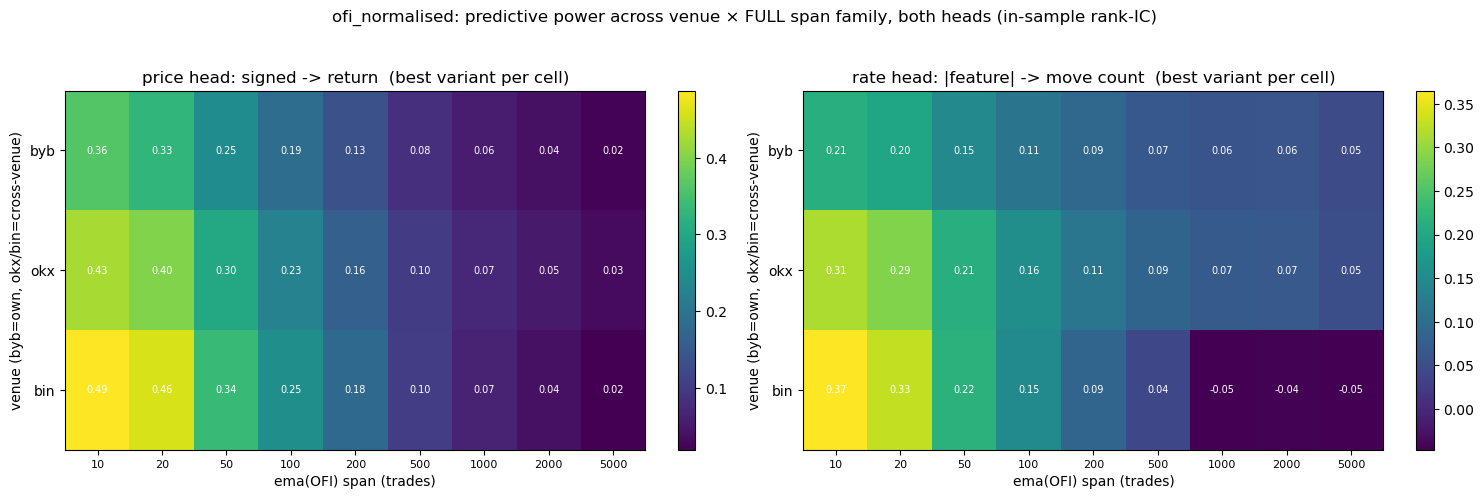

price head: overall best = 'none (raw)' on bin @ span 10  (in-sample IC +0.488)
rate  head: overall best = 'none (raw)' on bin @ span 10  (in-sample IC +0.365)
per-exchange best (price head), picked off the full grid:
  byb: 'none (raw)' @ span 10  (in-sample IC +0.363)
  okx: 'none (raw)' @ span 10  (in-sample IC +0.426)
  bin: 'none (raw)' @ span 10  (in-sample IC +0.488)


In [6]:
# Sweep venue × span × normalisation, BOTH heads. price head: signed feature -> byb's signed return; rate head: |feature| -> move count.
# Store full cube: grids[head][variant][ex] is a length-len(SPANS) array of IC.
price_cube = {nm: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for nm in VARIANTS}
rate_cube  = {nm: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for nm in VARIANTS}
feat_cache = {}   # (nm, ex, span) -> feature array (reused by the gates/§9)
for nm, fn in VARIANTS.items():
    for ex in EXCHANGES:
        for j, span in enumerate(SPANS):
            d = fn(ex, span); feat_cache[(nm, ex, span)] = d
            ok = np.isfinite(d) & np.isfinite(target)
            price_cube[nm][ex][j] = spearmanr(d[ok], target[ok]).statistic
            okr = np.isfinite(d) & np.isfinite(rate_target)
            rate_cube[nm][ex][j]  = spearmanr(np.abs(d[okr]), rate_target[okr]).statistic

# Per (head, venue, span) collapse to the BEST variant by |IC|, for a clean per-exchange heat-map across the FULL span family.
def best_variant_grid(cube):
    G = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
    which = {ex: [None] * len(SPANS) for ex in EXCHANGES}
    for ex in EXCHANGES:
        for j in range(len(SPANS)):
            vals = [(cube[nm][ex][j], nm) for nm in VARIANTS if np.isfinite(cube[nm][ex][j])]
            if vals:
                v, nm = max(vals, key=lambda t: abs(t[0])); G[ex][j] = v; which[ex][j] = nm
    return G, which
price_G, price_which = best_variant_grid(price_cube)
rate_G,  rate_which  = best_variant_grid(rate_cube)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (G, head) in zip(axes, [(price_G, "price head: signed -> return"), (rate_G, "rate head: |feature| -> move count")]):
    M = np.vstack([G[ex] for ex in EXCHANGES])
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8); ax.set_xlabel("ema(OFI) span (trades)")
    ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_ylabel("venue (byb=own, okx/bin=cross-venue)")
    ax.set_title(head + "  (best variant per cell)")
    for i in range(len(EXCHANGES)):
        for j in range(len(SPANS)):
            if np.isfinite(M[i, j]): ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("ofi_normalised: predictive power across venue × FULL span family, both heads (in-sample rank-IC)", y=1.03)
fig.tight_layout(); plt.show()

# pick the best (venue, variant, span) PER HEAD off the FULL grid — IN-SAMPLE, used ONLY to choose; re-scored OUT-OF-SAMPLE below.
def best_cell(cube):
    flat = [(cube[nm][ex][j], nm, ex, j) for nm in VARIANTS for ex in EXCHANGES for j in range(len(SPANS)) if np.isfinite(cube[nm][ex][j])]
    v, nm, ex, j = max(flat, key=lambda t: abs(t[0]))   # abs: the price head can be negatively signed; keep the strongest |IC|
    return nm, ex, j, v
# per-exchange best (variant, span) per head — picked off the grid for EACH venue
def best_cell_for(cube, ex):
    flat = [(cube[nm][ex][j], nm, j) for nm in VARIANTS for j in range(len(SPANS)) if np.isfinite(cube[nm][ex][j])]
    v, nm, j = max(flat, key=lambda t: abs(t[0])); return nm, j, v
p_nm, p_ex, p_j, p_v = best_cell(price_cube)
r_nm, r_ex, r_j, r_v = best_cell(rate_cube)
print(f"price head: overall best = '{p_nm}' on {p_ex} @ span {SPANS[p_j]}  (in-sample IC {p_v:+.3f})")
print(f"rate  head: overall best = '{r_nm}' on {r_ex} @ span {SPANS[r_j]}  (in-sample IC {r_v:+.3f})")
print("per-exchange best (price head), picked off the full grid:")
for ex in EXCHANGES:
    nm, j, v = best_cell_for(price_cube, ex)
    print(f"  {ex}: '{nm}' @ span {SPANS[j]}  (in-sample IC {v:+.3f})")

**Reading the heat-maps — and the normalisation verdict.** Each cell is an in-sample rank-IC for one
(venue, span), with the *best normalisation variant* picked per cell. The **price head** (left) is where
this feature lives: every venue's IC peaks at the **shortest span (10)** and falls monotonically as the
span lengthens — flow autocorrelation is strongest in the freshest book updates and washes out by the long
spans. In-sample power at span 10: **byb +0.363, okx +0.426, bin +0.488** — bin (its sub-ms-fresh feed) is
strongest, but okx and byb are comparably strong, so the price edge is **multi-venue**. The **rate head**
(right) peaks at the same cell (`none (raw)`, bin, span 10, +0.365). **The decisive result: the winning
normalisation is `none (raw)` for *every* venue and *both* heads** — the un-normalised `ema(OFI)` beats
both `/σ_ev` and `/λ_ev`. Dividing OFI by a byb yardstick *hurts* rank-IC here (it injects byb's regime as
per-row noise into a signal that is already a comparable per-book-update mean), so — per the guard rails'
"don't normalise reflexively" — `ofi_normalised` ships **un-normalised** on this block. The best
(venue, variant, span) per head is an in-sample pick used only to choose; the §5 gates re-score it OOS, and
the SHIPPED span checked in §4 is exactly this short end (10). We keep **every** venue.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:
  byb: best alt span  500 partial-IC|chosen -0.011;  OOS joint +0.343 vs solo +0.347 (Δ-0.005)  ->  one span suffices (no OOS gain)


  okx: best alt span   50 partial-IC|chosen +0.076;  OOS joint +0.396 vs solo +0.406 (Δ-0.010)  ->  one span suffices (no OOS gain)
  bin: best alt span   50 partial-IC|chosen +0.120;  OOS joint +0.445 vs solo +0.472 (Δ-0.027)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt span 2000 partial-IC|chosen +0.050;  OOS joint +0.185 vs solo +0.191 (Δ-0.006)  ->  one span suffices (no OOS gain)
  okx: best alt span   20 partial-IC|chosen +0.076;  OOS joint +0.289 vs solo +0.287 (Δ+0.002)  ->  one span suffices (no OOS gain)


  bin: best alt span   20 partial-IC|chosen +0.116;  OOS joint +0.331 vs solo +0.347 (Δ-0.016)  ->  one span suffices (no OOS gain)


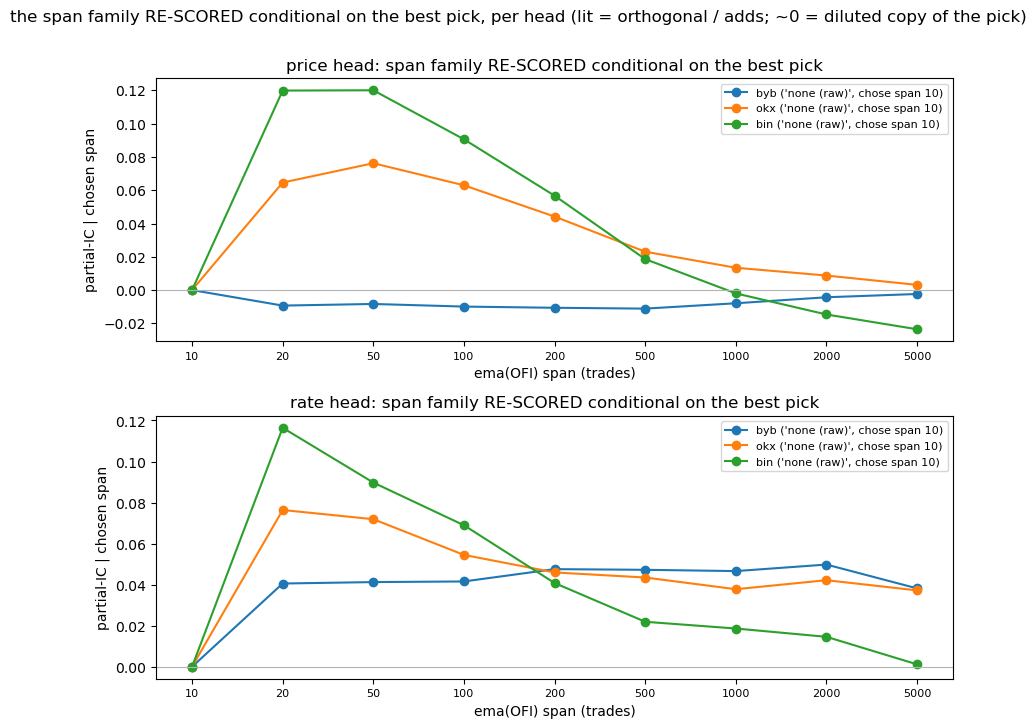

In [7]:
# === Does a SECOND time-scale ADD over the pick? — the span family RE-SCORED conditional on the best span, PER HEAD ===
# Selection lives here in §6. We picked the best (variant, span) per head/venue by IC; now re-score the WHOLE span
# family (holding each venue's chosen variant fixed) as partial-IC(span | chosen) — each span's IC against the head's
# target, CONTROLLING for the span we already picked (the same partial-IC tool the echo-netting cell uses; control =
# the chosen span, not the trailing move). A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES
# to ~0 is a diluted copy. The line is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC.
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: read() maps (variant, ex, span) -> its scored feature; tgt is the head's target; cube picks the in-sample best.
HEADS = [("price head", lambda nm, ex, span: feat_cache[(nm, ex, span)],         target,      price_cube),
         ("rate head",  lambda nm, ex, span: np.abs(feat_cache[(nm, ex, span)]), rate_target, rate_cube)]
fig, axes = plt.subplots(len(HEADS), 1, figsize=(9, 3.6 * len(HEADS)), squeeze=False)
second = {}
for row, (head, read, tgt, cube) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[row][0]
    for ex in EXCHANGES:
        c_nm, c_j, _ = best_cell_for(cube, ex)                        # this venue's chosen (variant, span) for the head
        chosen = read(c_nm, ex, SPANS[c_j])
        cond = np.full(len(SPANS), np.nan)                            # partial-IC(span | chosen), variant held at the pick's
        for j, span in enumerate(SPANS):
            cond[j] = 0.0 if j == c_j else _pic(read(c_nm, ex, span), tgt, chosen)
        ax.plot(range(len(SPANS)), cond, "o-", label=f"{ex} ('{c_nm}', chose span {SPANS[c_j]})")
        bj = int(np.nanargmax(np.abs(cond)))                          # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, read(c_nm, ex, SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)          # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                           # the OOS joint gain DECIDES
        second[(head, ex)] = SPANS[bj] if keep else None
        print(f"  {ex}: best alt span {SPANS[bj]:>4} partial-IC|chosen {cond[bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8); ax.set_xlabel("ema(OFI) span (trades)")
    ax.set_ylabel("partial-IC | chosen span"); ax.set_title(f"{head}: span family RE-SCORED conditional on the best pick"); ax.legend(fontsize=8)
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional
on the chosen pick** (holding each venue's chosen variant fixed) — each span's IC recomputed as
`partial-IC(span | chosen)`: its predictive power against the head's target **controlling for the span we already
picked** (the same partial-IC tool the echo-netting cell uses; control = the chosen span). A span that stays
**lit** is **orthogonal** — it adds new signal — while a span that **collapses to ≈ 0** is a diluted copy of the
pick. Because that line is **in-sample**, the keep/drop **decision** is the overfitting-resistant **walk-forward
joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample
gain clears the ~0.01 floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate →
|feature| vs the count target). On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span
per head suffices — the OFI edge lives at the single short span the §6 sweep picked, not in a span pair.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the variant/span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the pick. Held-out selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small span family × 3 variants of near-identical
neighbours, so the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate against),
**never** a control. Fail any one of them = a level in disguise, not a feature.

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `ofi_normalised`
is an order-flow **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all exchanges together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular; only its
cross-venue legs stay a marginal lead test.)* **Mechanical-coupling guard:** the gate scores the
**σ_ev price target** (`fwd_return/σ_ev`) by default. The `/σ_ev` variant of `ofi_normalised` divides by
that same yardstick — but it is a **signed price-head alpha** (the OFI numerator carries direction), and a
signed numerator should make the shared-σ_ev coupling negligible (verified by the §6 coupling rows, not
asserted) — so `STRAT_VAR = None`. We print the within-σ_ev stratified standalone IC below as that
confirmation.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [8]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). ofi_normalised is an alpha, so all legs take the marginal branch.

# each venue at its own best price-head (variant, span) off the §6 grid (the model input is the SIGNED feature)
ofi_feat = {ex: feat_cache[(best_cell_for(price_cube, ex)[0], ex, SPANS[best_cell_for(price_cube, ex)[1]])] for ex in EXCHANGES}
joint = signal_ic(list(ofi_feat.values()), own=False)
strat = signal_ic_by_regime(list(ofi_feat.values()), own=False)
pci = wf_marginal_ci(list(ofi_feat.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = ofi_feat[EXCHANGES[0]]                            # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all exchanges together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([ofi_feat[ex]], own=False)) for ex in EXCHANGES]
# H1 shared-σ_ev coupling check: the /σ_ev variant AND the σ_ev price target both divide by σ_ev. A SIGNED numerator
# should decouple that shared denominator — verify it (don't assert it): the standalone IC WITHIN σ_ev strata ≈ the
# unstratified standalone IC means σ_ev isn't manufacturing the rank-IC (spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed feature standalone IC, unstratified", value=round(ic(ofi_feat[ex], target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(ofi_feat[ex], target, sigma_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                   # GATE A PER EXCHANGE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(ofi_feat[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.491  |  per-fold [0.529, 0.521, 0.543, 0.435, 0.427] (positive in 5/5)  |  block-bootstrap 90% CI [0.474, 0.511]  (block ~2000 anchors ~100.0s)
FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.013 vol 0.004  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all exchanges together — marginal over the invariant control…",0.491
"""B · signal""","""byb alone — marginal over the controls""",0.327
"""B · signal""","""okx alone — marginal over the controls""",0.386
"""B · signal""","""bin alone — marginal over the controls""",0.46
"""B · coupling""","""byb — signed feature standalone IC, unstratified""",0.363
"""B · coupling""","""okx — signed feature standalone IC, unstratified""",0.426
"""B · coupling""","""bin — signed feature standalone IC, unstratified""",0.488
"""B · coupling""","""byb — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.357
"""B · coupling""","""okx — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.421


**Conclusion (price head).** `ofi_normalised` is an **alpha**, so Gate B is its marginal over the
controls — **and it passes strongly, multi-venue.** The all-venues **joint marginal is +0.491** (positive
in **5/5** OOS folds, block-bootstrap 90% CI **[0.474, 0.511]**, block ~2000 anchors ~100 s) — far above
the ~0.01 floor — and the venues are *not* collinear: **byb +0.327, okx +0.386, bin +0.460** alone, with
the joint (+0.491) larger than any single venue. The **coupling rows** confirm the shared-σ_ev decouple:
the within-σ_ev stratified standalone IC barely moves (byb 0.363→0.357, okx 0.426→0.421, bin 0.488→0.485),
so σ_ev isn't manufacturing the rank-IC — `STRAT_VAR = None` is justified *measured, not assumed* (and the
shipped variant is `none (raw)` anyway, which never divides by σ_ev). The feature's overlap with the
momenta is tiny (|IC| rate 0.013, vol 0.004), confirming it really is an alpha. The **byb** leg is partly
**circular** with the byb-derived controls (read +0.327 as "byb's own flow explains byb"); the **okx/bin**
legs are the genuinely new cross-venue lead test, and they add the most.

**Gate A is a mixed result and must be read honestly — it does *not* clear cleanly.** Run **per exchange**
(a distribution property — venues differ): **scale** wanders only **1.33 / 2.02 / 1.43×** (byb / okx / bin;
< 3, pass), and the **signed** feature barely tracks the regime (mean-track **0.016 / 0.037 / 0.063** —
byb/okx clear the ~0.05 bar, bin brushes just over it). But the **magnitude** the signed-fed rate head can
learn **fails the leak checks**: mag-track **0.139 / 0.177 / 0.096** (byb/okx over the ~0.1 bar) and
per-decile-mean dispersion **0.168 / 0.293 / 0.151** (all over the ~0.1 bar). So `|OFI|`'s *scale grows
with the regime* — raw OFI is a depth-scale size that is bigger when the book churns harder, and busier
books are more volatile; this is exactly the price the un-normalised reading pays. The **sign** is clean
(the price-head signal lives in the sign and is regime-stable), so the price head ships; the magnitude
Gate-A failure is a documented caveat for the **rate head** (gated below). The companion keeps the price
marginal positive — and rising — across regimes (**calm +0.483, mid +0.453, wild +0.500**). Verdict for the
**price head**: clears Gate B (joint +0.491, multi-venue, regime-stable) and the signed-feature Gate A;
the magnitude failure belongs to the rate head, not the price head.

**Now the rate head — its own gates, against the count target.** The block above gated the *price-pick*
feature against the σ_ev **price** target. The rate head is fed a **different** (variant, span) feature (the
rate-head pick) and predicts the **count** target, so its verdict is **not** inherited from the price gates
— it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because its **signed** numerator decouples the
shared σ_ev; the magnitude path has no sign to decouple it, and `|feature|`'s `/σ_ev` or `/λ_ev` divisor
can share the byb-activity regime with `count/λ_ev ∝ 1/λ_ev` — so we add a **within-λ_ev stratified** line
per exchange to confirm the marginal isn't a `1/λ_ev` artefact. **Gate A** is re-run **per exchange** on
the rate-pick feature (a distribution property — it differs by venue, variant *and* span).

In [9]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-pick feature against the σ_ev price target. The rate head is fed a
# DIFFERENT (variant, span) feature (the rate-head pick) and predicts the COUNT target, so its verdict can't be
# inherited from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature|.
#  * Coupling guard: add a within-λ_ev stratified line per exchange to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER EXCHANGE on the rate-pick feature (a distribution property — it differs by venue, variant AND span).
ofi_rate_signed = {ex: feat_cache[(best_cell_for(rate_cube, ex)[0], ex, SPANS[best_cell_for(rate_cube, ex)[1]])] for ex in EXCHANGES}
mag_rate        = {ex: np.abs(ofi_rate_signed[ex]) for ex in EXCHANGES}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all exchanges together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in EXCHANGES]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:
    a = gate_a(ofi_rate_signed[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.310  |  per-fold [0.355, 0.312, 0.325, 0.328, 0.231] (positive in 5/5)  |  block-bootstrap 90% CI [0.302, 0.34]  (block ~2000 anchors ~100.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all exchanges together — marginal |feature|->count over the controls; …",0.31
"""B · signal (rate)""","""byb alone — marginal |feature|->count over the controls""",0.099
"""B · signal (rate)""","""okx alone — marginal |feature|->count over the controls""",0.184
"""B · signal (rate)""","""bin alone — marginal |feature|->count over the controls""",0.259
"""B · coupling (rate)""","""byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.19
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.29
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.353
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.33
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.016


**Conclusion (rate head).** The rate-pick feature (each venue's own in-sample rate (variant, span) — here
all three land on `none (raw)` at short spans) is gated against the **count** target through the same
purged walk-forward. **Gate B is clearly positive OOS.** The joint marginal `|feature| → count` over the
controls is **+0.310** (positive in **5/5** OOS folds, CI **[0.302, 0.34]**), per-venue **byb +0.099, okx
+0.184, bin +0.259** — bin the strongest, all above the ~0.01 floor. *Within* **λ_ev strata** the signal
stays robustly positive (**byb 0.190, okx 0.290, bin 0.353**), so the marginal is **not** a `1/λ_ev`
arithmetic artefact. The **companion** is positive in every regime (**calm +0.347, mid +0.324, wild
+0.310**).

**But the same Gate-A magnitude caveat bites the rate head harder — it does not clear cleanly.** Scale
(1.33 / 2.02 / 1.43) and signed mean-track (0.016 / 0.037 / 0.063) pass, but the rate head is fed and keys
on **`|OFI|`**, and `|OFI|` **fails** the magnitude leak checks: mag-track **0.139 / 0.177 / 0.096**
(byb/okx over ~0.1) and dispersion **0.168 / 0.293 / 0.151** (all over ~0.1), because the raw OFI magnitude
is a depth-scale size that rides the volatility/activity regime (busier books → bigger `|OFI|` *and* more
byb moves). So the rate-head edge is a **real OOS intensity signal (joint +0.310) entangled with the regime
through its magnitude** — the within-λ_ev strata line is the reassurance that some of it is genuine (it
survives conditioning on the rate yardstick). The honest read: the rate head carries OOS signal but its
Gate A is **failed on the magnitude/dispersion checks** — ship it only with the §8 robust-z + clip (which
bounds the scale the model sees) and watch it across blocks; do **not** claim clean regime-invariance for
the rate head. The verdict for the rate head is read off **this** table, not inherited from the price gates.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

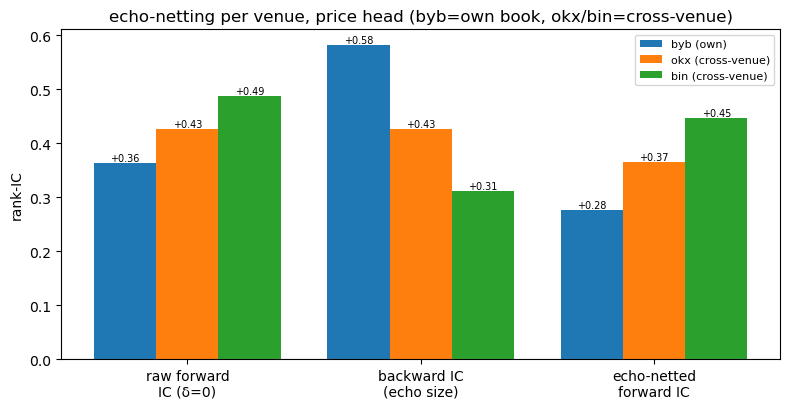

  byb (own book, 'none (raw)', span 10):  raw forward +0.363;  backward (echo) +0.581;  echo-netted +0.277  (raw->netted shortfall = echo)
  okx (cross-venue, 'none (raw)', span 10):  raw forward +0.426;  backward (echo) +0.426;  echo-netted +0.366  (raw->netted shortfall = echo)
  bin (cross-venue, 'none (raw)', span 10):  raw forward +0.488;  backward (echo) +0.312;  echo-netted +0.446  (raw->netted shortfall = echo)


In [10]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
# Run it for EVERY venue — the cross-venue verdict (§10) leans on the byb-vs-okx/bin echo comparison, so we
# measure raw / backward / echo-netted forward IC for each leg rather than asserting them.
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict (target venue byb)
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
echo = {}                                                 # ex -> (chosen variant/span, raw IC, backward/echo IC, echo-netted IC)
for ex in EXCHANGES:
    e_nm, e_j, _ = best_cell_for(price_cube, ex)          # this venue's chosen price-head (variant, span) off the §6 grid
    signed = feat_cache[(e_nm, ex, SPANS[e_j])]           # the chosen price-head feature (signed ema(OFI) reading)
    raw_ic   = _ic(signed, _fwd0)                         # raw forward IC
    back_ic  = _ic(signed, _trail)                        # backward IC — sizes the contemporaneous echo
    echo_net = _partial_ic(signed, _fwd0, _trail)         # forward IC NETTED of the echo (controls for the trailing move)
    echo[ex] = (e_nm, SPANS[e_j], raw_ic, back_ic, echo_net)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
groups = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
x = np.arange(len(groups)); w = 0.8 / len(EXCHANGES)
for k, ex in enumerate(EXCHANGES):
    _, _, raw_ic, back_ic, echo_net = echo[ex]
    vals = [raw_ic, back_ic, echo_net]
    bars = ax.bar(x + (k - (len(EXCHANGES) - 1) / 2) * w, vals, w, label=f"{ex} (own)" if ex == "byb" else f"{ex} (cross-venue)")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=7)
ax.axhline(0, color="0.7", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("rank-IC"); ax.set_title("echo-netting per venue, price head (byb=own book, okx/bin=cross-venue)"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
for ex in EXCHANGES:
    e_nm, e_span, raw_ic, back_ic, echo_net = echo[ex]
    leg = "own book" if ex == "byb" else "cross-venue"
    print(f"  {ex} ({leg}, '{e_nm}', span {e_span}):  raw forward {raw_ic:+.3f};  backward (echo) {back_ic:+.3f};  echo-netted {echo_net:+.3f}  (raw->netted shortfall = echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.) For `ofi_normalised`, OFI is near-linear in the *contemporaneous*
book move, so we expect byb's own-book leg (its book moves the very byb mid it predicts) to carry the most echo
and net down hardest, while the foreign okx/bin legs — which read *another* venue's book — should net down far
less. **The per-venue table above bears this out (all `none (raw)`, span 10):** byb nets down hardest — raw
**+0.363**, backward (echo) **+0.581** (echo *larger* than the forward edge), netted **+0.277** (a 0.086 drop);
**okx** nets down moderately — raw **+0.426**, backward **+0.426** (echo equals the forward edge), netted
**+0.366** (0.060 drop); and **bin** nets down least — raw **+0.488**, backward **+0.312** (echo *smaller* than
the forward edge), netted **+0.446** (just 0.042). So bin is the cleanest cross-venue lead (most of its edge
survives netting, its backward IC sitting well *below* its forward IC), okx a solid one, and byb is largely an
own-book echo — exactly the ordering the mechanism predicts.

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature (byb's winning variant/span — the strong leg) and look at the real distributions the two heads
care about: the price head's signed forward return across feature buckets, and the rate head's move-count
vs the feature's magnitude.

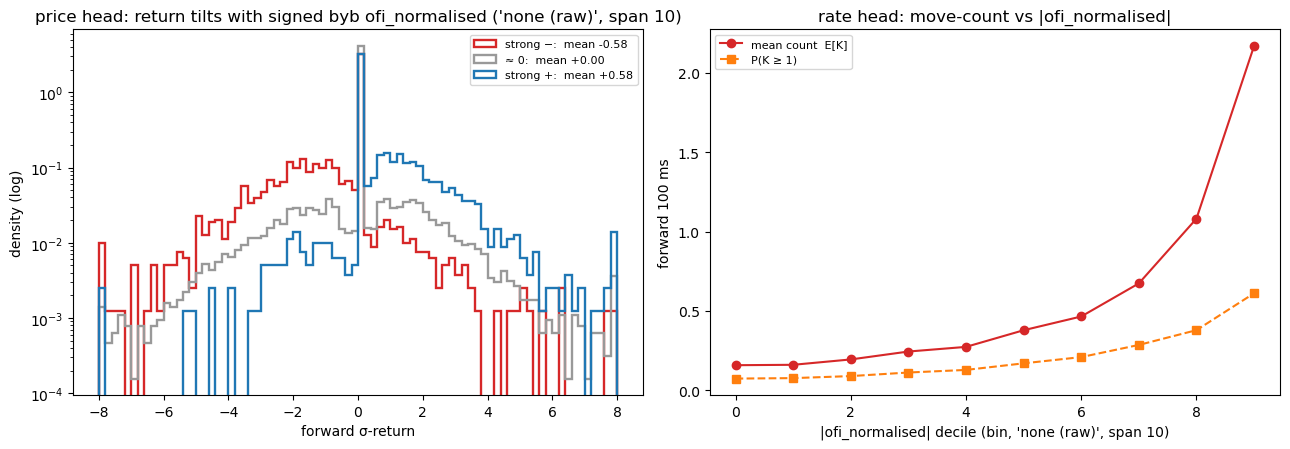

In [11]:
byb_pnm, byb_pj, _ = best_cell_for(price_cube, "byb")
signed = feat_cache[(byb_pnm, "byb", SPANS[byb_pj])]                          # byb's winning price-head reading
ar_nm, ar_ex, ar_j, _ = best_cell(rate_cube)                                 # rate head's overall best (variant, venue, span)
absmag = np.abs(feat_cache[(ar_nm, ar_ex, SPANS[ar_j])])
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-OFI buckets
fin = np.isfinite(signed)
lo, hi = np.nanpercentile(signed[fin], [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with signed byb ofi_normalised ('{byb_pnm}', span {SPANS[byb_pj]})"); axA.legend(fontsize=8)

# rate head: forward move-count vs |feature| decile
finm = np.isfinite(absmag)
dec = np.full(absmag.shape, -1); dec[finm] = np.digitize(absmag[finm], np.nanpercentile(absmag[finm], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel(f"|ofi_normalised| decile ({ar_ex}, '{ar_nm}', span {SPANS[ar_j]})"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |ofi_normalised|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The plots show `ofi_normalised` moving the *actual outcome distributions* the two heads
need — not just a single summary number (shown here for byb's own `none (raw)` span-10 leg; the rate panel
uses the overall best rate cell, bin `none (raw)` span 10; the model uses every venue). **Price head
(left):** the forward-return distribution shifts bodily with the *signed* feature — positive OFI (more
bid-side pressure) tilts the mean return up, negative tilts it down, with the ≈0 group flat between (read
the group means in the legend) — so the sign genuinely carries direction (the feature's main job),
consistent with byb's positive signed price-head IC (+0.363 in §6) and the §1 mechanism. **Rate head
(right):** both the mean move-count `E[K]` and `P(K ≥ 1)` climb monotonically with the |OFI| decile — a
larger imbalance magnitude really does precede more byb moves, the secondary intensity signal §5 gates OOS
(joint +0.310). So both heads have something to learn here, in the directions §1 predicted.

## 8. Input shaping for the network

This is a *different* step from §2's regime division. Here we reshape the feature for the network's
input — roughly centred, unit-scale, no wild outliers — picking the **lightest** transform that does the
job. An OFI EMA divided by a yardstick is a ratio of two stochastic quantities, so it tends to be
heavier-tailed and more skewed than a bounded imbalance; the QQ-plot makes the choice. We shape byb's
winning leg; the okx/bin legs share the same construction and shape similarly.

byb feature ('none (raw)', span 10): std=39  skew=+0.43  excess_kurt=13.9  (0 = normal)
  z-score            excess_kurt=    13.9   max|·|=14.5
  robust + clip ±4   excess_kurt=     0.7   max|·|=4.0
  arcsinh(robust)    excess_kurt=     0.4   max|·|=4.4
  rank-Gaussian      excess_kurt=    -0.0   max|·|=4.2


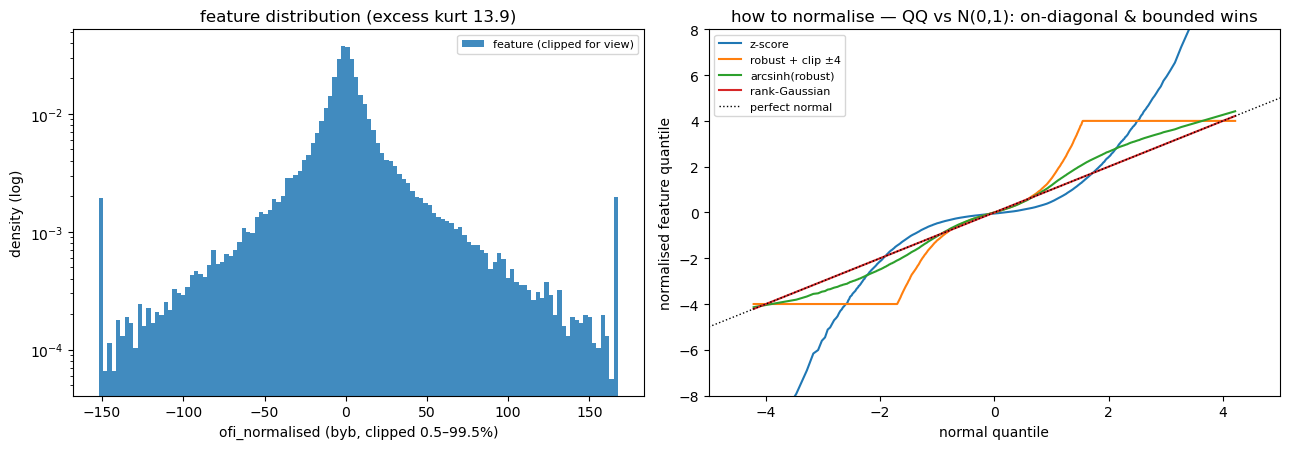

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = feat_cache[(byb_pnm, "byb", SPANS[byb_pj])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"byb feature ('{byb_pnm}', span {SPANS[byb_pj]}): std={f.std():.2g}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>8.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
lo_p, hi_p = np.percentile(f, [0.5, 99.5])
axA.hist(np.clip(f, lo_p, hi_p), bins=120, density=True, color="C0", alpha=.85, label="feature (clipped for view)")
axA.set_yscale("log"); axA.set_xlabel("ofi_normalised (byb, clipped 0.5–99.5%)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_ylim(-8, 8); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles the transform. byb's winning leg (`none (raw)` span 10) is the
**un-normalised** `ema(OFI)` — a depth-scale size — so it is near-symmetric (skew **+0.43**) but strongly
fat-tailed (excess kurtosis **13.9**, std **39**): depth events span orders of magnitude. A plain z-score
therefore leaves a wild **14.5σ** outlier (`max|·| = 14.5`) and fails the "no wild outliers" bar. The
lightest transform that *meets* it is a robust z-score followed by a clip (**robust + clip ±4 → excess
kurt 0.7, max|·| = 4.0**). The heavier maps barely improve on that (arcsinh(robust) → kurt 0.4, max 4.4;
rank-Gaussian → kurt −0.0, max 4.2) and would throw away the meaningful gradations near the centre. The
QQ-plot points to the on-diagonal, bounded curve — use **robust + clip ±4** whenever you feed a network
(it is also what bounds the magnitude Gate-A failure's input scale for the rate head).

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for a poolable feature)

`ofi_normalised` is **poolable** — each venue yields its own one-number `ema(OFI)` from its own book — so
unlike the template's cross-venue gap, you face a real choice: keep them **per-exchange**, collapse to
**one** (byb's own book, the most direct), or **pool** them all into one number. The right answer depends
on the time-scale, so sweep it and compare the three:
- **pooled** — one OFI flow over *all* venues' book updates on the shared clock, read as one `ema(OFI)`;
- **best single** — the single most predictive venue's OFI (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by **marginal walk-forward** rank-IC over the controls (against byb's next return), at a
short, a medium, and a long span. Use the `/σ_ev` variant throughout for a clean apples-to-apples sweep
(the §6 table already compared variants). The template's prediction for a cross-venue lead/lag signal: at
**short** lookbacks the venues genuinely differ (who leads whom is live), so per-exchange carries distinct
value; at **long** lookbacks the lead/lag is long gone and one venue (or a pool) suffices.

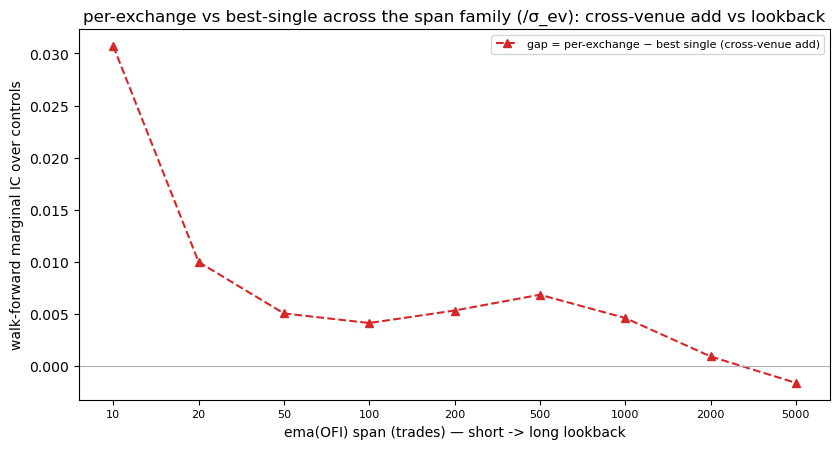

shape: (3, 5)
┌───────────────────┬────────┬─────────────┬──────────────┬─────────────────┐
│ time_scale        ┆ pooled ┆ best_single ┆ per_exchange ┆ cross_venue_add │
│ ---               ┆ ---    ┆ ---         ┆ ---          ┆ ---             │
│ str               ┆ f64    ┆ str         ┆ f64          ┆ f64             │
╞═══════════════════╪════════╪═════════════╪══════════════╪═════════════════╡
│ short (span=10)   ┆ 0.448  ┆ 0.46 (bin)  ┆ 0.491        ┆ 0.031           │
│ medium (span=200) ┆ 0.142  ┆ 0.144 (bin) ┆ 0.149        ┆ 0.005           │
│ long (span=5000)  ┆ 0.008  ┆ 0.01 (bin)  ┆ 0.008        ┆ -0.002          │
└───────────────────┴────────┴─────────────┴──────────────┴─────────────────┘
cross-venue add (per-exchange − best single): short (span 10) +0.031  ->  long (span 5000) -0.002


In [13]:
# pooled OFI: concatenate ALL venues' book-update increments onto the shared clock, then the same E/W ema, /σ_ev.
pool_rx_cat = np.concatenate([ofi_rx_by_ex[ex] for ex in EXCHANGES])
pool_e_cat  = np.concatenate([ofi_e_by_ex[ex]  for ex in EXCHANGES])
_po = np.argsort(pool_rx_cat, kind="stable")                      # rx ascending (each venue's increment kept as its own sample)
pool_rx, pool_e = pool_rx_cat[_po], pool_e_cat[_po]
def pooled_ofi_over_sigma(span):                                  # one ema(OFI) over all venues' book updates, /σ_ev
    E = _flow_at(anchor_ts, pool_rx, pool_e, span); W = _flow_at(anchor_ts, pool_rx, np.ones_like(pool_e), span)
    return (E / np.maximum(W, 1e-12)) / sigma_at_anchor

VAR9 = "/ σ_ev (vol)"
base_ic = wf_ic(base, target)
SHORT, MED, LONG = SPANS[0], SPANS[len(SPANS) // 2], SPANS[-1]
single_ic, perex_ic, pooled_ic, gap_ic = [], [], [], []
scan = [("short", SHORT), ("medium", MED), ("long", LONG)]
rows = []
for label, span in scan:
    per_ex    = [feat_cache[(VAR9, ex, span)] for ex in EXCHANGES]
    single    = {ex: wf_ic(base + [feat_cache[(VAR9, ex, span)]], target) - base_ic for ex in EXCHANGES}
    best_ex   = max(single, key=single.get)
    s_ic = round(single[best_ex], 3)
    p_ic = round(wf_ic(base + per_ex, target) - base_ic, 3)                       # per-exchange (all 3)
    pl_ic = round(wf_ic(base + [pooled_ofi_over_sigma(span)], target) - base_ic, 3)  # pooled
    single_ic.append(s_ic); perex_ic.append(p_ic); pooled_ic.append(pl_ic); gap_ic.append(round(p_ic - s_ic, 3))
    rows.append(dict(time_scale=f"{label} (span={span})", pooled=pl_ic, best_single=f"{s_ic} ({best_ex})",
                     per_exchange=p_ic, cross_venue_add=round(p_ic - s_ic, 3)))

# also sweep the cross-venue add (per-exchange − best-single) across the FULL span family for the convergence picture
full_gap = []
for span in SPANS:
    per_ex = [feat_cache[(VAR9, ex, span)] for ex in EXCHANGES]
    single = max(wf_ic(base + [feat_cache[(VAR9, ex, span)]], target) - base_ic for ex in EXCHANGES)
    full_gap.append(wf_ic(base + per_ex, target) - base_ic - single)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(range(len(SPANS)), full_gap, "^--", color="C3", label="gap = per-exchange − best single (cross-venue add)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8)
ax.set_xlabel("ema(OFI) span (trades) — short -> long lookback"); ax.set_ylabel("walk-forward marginal IC over controls")
ax.set_title("per-exchange vs best-single across the span family (/σ_ev): cross-venue add vs lookback")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

tbl9 = pl.DataFrame(rows)
print(tbl9)
print(f"cross-venue add (per-exchange − best single): short (span {SPANS[0]}) {full_gap[0]:+.3f}  ->  long (span {SPANS[-1]}) {full_gap[-1]:+.3f}")

**Conclusion.** Marginal walk-forward rank-IC over the controls for **pooled** vs **best single** vs
**per-exchange**, at a short / medium / long span, plus the cross-venue add (per-exchange − best single)
across the full span family. On this block:
- **short (span 10):** per-exchange **0.491** > best single **0.460 (bin)** > pooled **0.448** — at the
  freshest scale the venues genuinely differ (who's leaning *now*), so keeping all three pays a real
  **+0.031** over the best single venue, and pooling already starts to blur it.
- **medium (span 200):** per-exchange **0.149** ≳ best single **0.144 (bin)** > pooled **0.142** — the
  edge is mostly shared by now; per-exchange still edges single by a slim **+0.005**.
- **long (span 5000):** all three are ≈0 (pooled 0.008, best single 0.010, per-exchange 0.008,
  cross-venue add **−0.002**) — the flow has smoothed to a common drift with no residual edge.

So the per-exchange/pool choice is real and **time-scale-dependent**: the cross-venue add is **+0.031 at
the shortest span and decays monotonically to ≈0 (−0.002) by the longest** — the classic lead/lag cross-over.
**Keep all three venues** as the safe default and weight them most at short spans, where per-exchange wins
and the cross-venue okx/bin legs lead byb; pooling is never strictly best here and *loses* at the short
scale, exactly as the guard rails anticipate for a poolable cross-venue feature. (Longer prediction
horizons widen the useful band, so sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed*, §8-shaped OFI to both heads (each head gated separately in §6), all
exchanges, at the short span. The direction edge is strong and genuinely multi-venue; the one honest
caveat is that `|OFI|` (what the rate head keys on) is *not* regime-invariant — it fails Gate A's
magnitude/dispersion checks — so the rate head ships only behind the §8 clip and on watch.** The §6
heat-map cells are in-sample picks; the §5 walk-forward marginals are the verdict.
- *Which normalisation — `none` (un-normalised) wins.* The §6 sweep is decisive: `none (raw)` beats both
  `/σ_ev` and `/λ_ev` for **every venue and both heads**. So `ofi_normalised` ships **un-normalised** on
  this block — dividing by a byb yardstick injects byb's regime as per-row noise and *lowers* rank-IC,
  exactly the guard rails' "don't normalise reflexively." (The name is a misnomer for the shipped reading;
  the analysis is what earns the choice.) The dimensional caveat is moot here since we divide by nothing.
- *Which span, per head — one span suffices.* §6's IC sweep peaks at the **shortest span (10)** for both
  heads, and §6's conditional-IC test confirms a **single span** is enough: re-scoring the family as
  `partial-IC(span | chosen)` and deciding on the walk-forward joint-vs-solo OOS gain, the best alternative
  span adds **≈0 OOS** for every venue and both heads — it is a diluted copy of the pick, not an orthogonal
  second time-scale. So ship the short span (10) per head; no span pair is warranted.
- *Which venues* — keep **all three** legs (no fixed leader). The price edge is **multi-venue**: each
  venue's signed OFI clears the walk-forward gate over the controls (byb **+0.327**, okx **+0.386**, bin
  **+0.460**), and the **all-venues joint marginal is +0.491 — larger than any single venue** (5/5 OOS
  folds, CI [0.474, 0.511]), so they are *not* collinear and pooling to one venue loses signal. But the
  honest cross-venue number is **net of echo** (the echo-netting section):
  - **byb (own)** is partly circular with the byb-derived controls and reads the very book that moves
    byb's mid — its backward/echo IC (**+0.581**) is *larger* than its raw forward IC (**+0.363**), so it
    **nets down hardest** to **+0.277** (a 0.086 drop, the biggest of the three). Useful own-flow signal,
    largely an own-book echo, not a cross-venue discovery.
  - **okx / bin (cross-venue)** are genuine leads, not echoes — and they discount **far less** than byb
    (all measured in the echo-netting section, `none (raw)`, span 10): **bin** discounts least (raw
    **+0.488** → netted **+0.446**, just 0.042; backward **+0.312** sits *below* its forward IC — the
    cleanest lead), and **okx** moderately (raw **+0.426** → netted **+0.366**, 0.060; backward **+0.426**
    *equals* its forward IC). Most of each foreign leg's edge survives netting, the mark of a genuine
    cross-venue lead. Per the guard rails, that freshness lead is *real edge* recorded at live production
    timing — not an artifact to coarsen away.
  - §9: the cross-venue legs add **+0.031 over the best single venue at the short span**, decaying to
    **≈0 (−0.002) by the longest span** — the classic lead/lag cross-over.

Feed the **signed** feature to both heads at the short span; the rate head learns the magnitude itself.
The rate head's Gate B is positive OOS (joint **+0.310**, 5/5 folds, within-λ_ev strata +0.190/+0.290/+0.353)
but it keys on `|OFI|`, whose magnitude **fails** Gate A (mag-track 0.139/0.177/0.096, dispersion
0.168/0.293/0.151) because the depth-scale magnitude rides the regime — ship the rate head only behind the
§8 robust-z + clip ±4 (which bounds the scale the model sees) and watch it across blocks; do **not** claim
clean regime-invariance for the rate head.

**To ship:**
- [x] the streaming (constant-work-per-event) builder, matching this analysis version — done (§4, production-style `boba.ema` `KernelMeanEMA`, parity to floating-point precision for **all three** venues, max|diff| ~1e-11)
- [x] the §4 parity check and tests, passing for every per-exchange leg
- [x] both heads gated **out-of-sample** (§5 walk-forward); rate head scored against `count÷λ_ev`
- [x] echo-netted forward IC reported **per venue** — byb's own-book leg nets down hardest (raw +0.363 → netted +0.277, backward echo +0.581 > forward); the okx/bin cross-venue legs discount far less (bin +0.488 → +0.446, backward +0.312 *below* forward; okx +0.426 → +0.366, backward +0.426 ≈ forward), the mark of a genuine lead
- [x] the chosen normalisation + span(s) per head written down: **`none` (un-normalised) wins**, short span (10) both heads; yardstick span `YARDSTICK_N` = 10000 (used for the targets/controls only)
- [x] the per-exchange decision recorded: keep all three; cross-venue okx/bin add **+0.031** over byb at the short span, decaying to ≈0 by the longest span (§9) — a real, short-horizon cross-venue lead
- [x] the gate results recorded **with the failure justified** — price Gate B **+0.491** joint (multi-venue), signed-feature Gate A clears (scale < 3, signed mean-track ≤ 0.063); **Gate A FAILS on `|OFI|` magnitude** (mag-track 0.10–0.18, dispersion 0.15–0.29) — the depth-scale magnitude rides the regime, mitigated (not cured) by the §8 clip; rate head OOS **+0.310** but inherits that caveat
- [x] the data quirks handled (bad zero-price trade prints filtered; OFI uses **front_levels** for
      `bid_qty`/`ask_qty`, since `merged_levels` is price-only; same-`rx_time` book bursts collapsed to
      one event; the SHARED trade clock ticks every venue's OFI EMA)